# Play Tennis Prediction using Categorical Naive Bayes

**Lab 8 — Categorical Naive Bayes Classifier**

This notebook implements a Categorical Naive Bayes model on the *Play Tennis* dataset to predict whether tennis will be played given weather conditions. It also compares the model's performance against a Decision Tree and Logistic Regression classifier.

**Tasks covered:**
1. Separate input features and target variable
2. Encode categorical values into numerical values
3. Split the dataset into training and testing sets
4. Train a Categorical Naive Bayes model
5. Predict class labels for the test set
6. Calculate accuracy, confusion matrix, and classification report
7. Predict a new weather condition with class probabilities
8. Compare performance with Decision Tree and Logistic Regression

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load and Explore the Dataset

The dataset contains 50 records describing weather conditions (`Outlook`, `Temperature`, `Humidity`, `Wind`) and whether tennis was played (`Play Tennis`).

In [2]:
df = pd.read_csv("PlayTennis.csv")
print("Shape:", df.shape)
df.head(10)

Shape: (50, 6)


,No,Outlook,Temperature,Humidity,Wind,Play Tennis
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Overcast,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes
5,6,Rain,Cool,Normal,Strong,No
6,7,Overcast,Cool,Normal,Strong,Yes
7,8,Sunny,Mild,High,Weak,No
8,9,Sunny,Cool,Normal,Weak,Yes
9,10,Rain,Mild,Normal,Weak,Yes


In [3]:
# Drop the record-id column, it carries no predictive information
df = df.drop(columns=["No"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Outlook      50 non-null     str  
 1   Temperature  50 non-null     str  
 2   Humidity     50 non-null     str  
 3   Wind         50 non-null     str  
 4   Play Tennis  50 non-null     str  
dtypes: str(5)
memory usage: 2.1 KB


In [4]:
# Quick look at class balance
df["Play Tennis"].value_counts()

Play Tennis
Yes    34
No     16
Name: count, dtype: int64

## 3. Separate Input Features and Target Variable

In [5]:
X = df.drop(columns=["Play Tennis"])   # Outlook, Temperature, Humidity, Wind
y = df["Play Tennis"]                   # Yes / No

print("Features:", list(X.columns))
print("Target:", y.name)

Features: ['Outlook', 'Temperature', 'Humidity', 'Wind']
Target: Play Tennis


## 4. Encode Categorical Values into Numerical Values

All four features (`Outlook`, `Temperature`, `Humidity`, `Wind`) and the target (`Play Tennis`) are categorical (nominal) strings.

- **`OrdinalEncoder`** is used on the input features. This is the appropriate choice here because `CategoricalNB` expects each feature to be encoded as a non-negative integer index representing its category (it internally treats every column as a distinct categorical distribution, so there is no assumption of order despite the numeric codes).
- **`LabelEncoder`** is used on the target variable to convert `Yes`/`No` into `1`/`0`.

(One-Hot Encoding is deliberately **not** used for the Naive Bayes model — Categorical NB is designed to work directly on label-encoded categorical columns, not on expanded binary dummy columns.)

In [6]:
feature_encoder = OrdinalEncoder()
X_encoded = pd.DataFrame(
    feature_encoder.fit_transform(X),
    columns=X.columns
).astype(int)

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Encoded categories per feature:")
for col, cats in zip(X.columns, feature_encoder.categories_):
    print(f"  {col}: {list(cats)}")
print("\nTarget classes:", list(target_encoder.classes_), "->", list(target_encoder.transform(target_encoder.classes_)))

X_encoded.head()

Encoded categories per feature:
  Outlook: ['Overcast', 'Rain', 'Sunny']
  Temperature: ['Cool', 'Hot', 'Mild']
  Humidity: ['High', 'Normal']
  Wind: ['Strong', 'Weak']

Target classes: ['No', 'Yes'] -> [np.int64(0), np.int64(1)]


,Outlook,Temperature,Humidity,Wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1


## 5. Split the Dataset into Training and Testing Sets

An 80/20 train-test split is used, stratified on the target so both classes are represented proportionally in the test set.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)

Training set size: (40, 4)
Testing set size : (10, 4)


## 6. Train a Categorical Naive Bayes Model

In [8]:
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


## 7. Predict Class Labels for the Test Dataset

In [9]:
y_pred_nb = nb_model.predict(X_test)

results = pd.DataFrame({
    "Actual": target_encoder.inverse_transform(y_test),
    "Predicted": target_encoder.inverse_transform(y_pred_nb)
})
results

,Actual,Predicted
0,No,Yes
1,Yes,Yes
2,No,No
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,No,No
9,Yes,Yes


## 8. Accuracy, Confusion Matrix, and Classification Report

In [10]:
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Categorical Naive Bayes Accuracy: {acc_nb:.4f} ({acc_nb*100:.2f}%)")

Categorical Naive Bayes Accuracy: 0.9000 (90.00%)


Confusion Matrix:
 [[2 1]
 [0 7]]


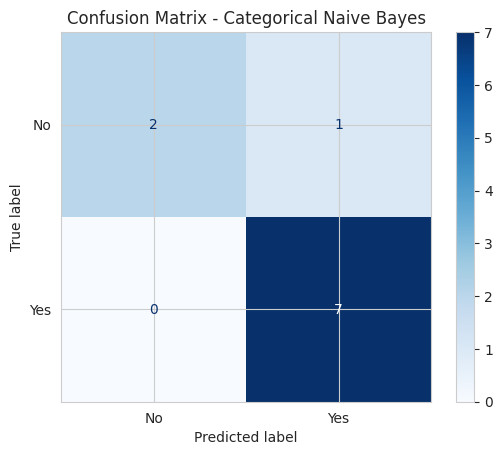

In [11]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("Confusion Matrix:\n", cm_nb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=target_encoder.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Categorical Naive Bayes")
plt.show()

In [12]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_nb, target_names=target_encoder.classes_))

Classification Report:

              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10



## 9. Predict a New Weather Condition

Predict whether tennis will be played for:
- **Outlook:** Sunny
- **Temperature:** Cool
- **Humidity:** High
- **Wind:** Strong

In [13]:
new_sample = pd.DataFrame([{
    "Outlook": "Sunny",
    "Temperature": "Cool",
    "Humidity": "High",
    "Wind": "Strong"
}])

new_sample_encoded = pd.DataFrame(
    feature_encoder.transform(new_sample[X.columns]),
    columns=X.columns
).astype(int)

predicted_class = nb_model.predict(new_sample_encoded)
predicted_proba = nb_model.predict_proba(new_sample_encoded)

predicted_label = target_encoder.inverse_transform(predicted_class)[0]

print("New sample:", new_sample.to_dict(orient="records")[0])
print("\nPredicted class:", predicted_label)

print("\nClass probabilities:")
for cls, prob in zip(target_encoder.classes_, predicted_proba[0]):
    print(f"  P(Play Tennis = {cls}) = {prob:.4f}")

New sample: {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'}

Predicted class: No

Class probabilities:
  P(Play Tennis = No) = 0.7894
  P(Play Tennis = Yes) = 0.2106


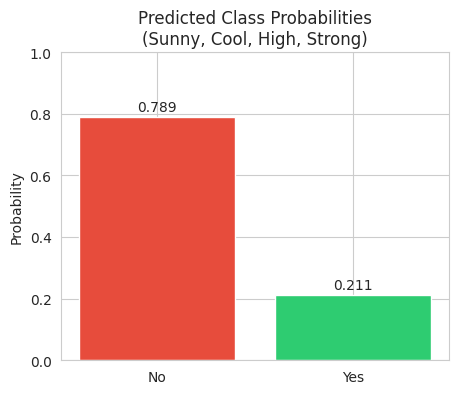

In [14]:
# Visualize the predicted probabilities
plt.figure(figsize=(5, 4))
plt.bar(target_encoder.classes_, predicted_proba[0], color=["#e74c3c", "#2ecc71"])
plt.ylabel("Probability")
plt.title("Predicted Class Probabilities\n(Sunny, Cool, High, Strong)")
plt.ylim(0, 1)
for i, p in enumerate(predicted_proba[0]):
    plt.text(i, p + 0.02, f"{p:.3f}", ha="center")
plt.show()

## 10. Compare Performance with Decision Tree and Logistic Regression

For a fair comparison, the Decision Tree and Logistic Regression models are trained using **One-Hot Encoded** features (the conventional encoding for these algorithms), using the *same* train/test split indices as the Naive Bayes model.

In [15]:
ohe = OneHotEncoder(sparse_output=False)
X_ohe = pd.DataFrame(
    ohe.fit_transform(X),
    columns=ohe.get_feature_names_out(X.columns)
)

# Reuse the same row split as before (indices align since X_encoded and X_ohe
# were both derived from X in original row order)
X_train_ohe = X_ohe.loc[X_train.index]
X_test_ohe  = X_ohe.loc[X_test.index]

X_ohe.head()

,Outlook_Overcast,Outlook_Rain,Outlook_Sunny,Temperature_Cool,Temperature_Hot,Temperature_Mild,Humidity_High,Humidity_Normal,Wind_Strong,Wind_Weak
0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [16]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_ohe, y_train)
y_pred_dt = dt_model.predict(X_test_ohe)
acc_dt = accuracy_score(y_test, y_pred_dt)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_ohe, y_train)
y_pred_lr = lr_model.predict(X_test_ohe)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Decision Tree Accuracy      : {acc_dt:.4f} ({acc_dt*100:.2f}%)")
print(f"Logistic Regression Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)")

Decision Tree Accuracy      : 1.0000 (100.00%)
Logistic Regression Accuracy: 0.9000 (90.00%)


In [17]:
print("Decision Tree - Classification Report:\n")
print(classification_report(y_test, y_pred_dt, target_names=target_encoder.classes_, zero_division=0))

print("Logistic Regression - Classification Report:\n")
print(classification_report(y_test, y_pred_lr, target_names=target_encoder.classes_, zero_division=0))

Decision Tree - Classification Report:

              precision    recall  f1-score   support

          No       1.00      1.00      1.00         3
         Yes       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

Logistic Regression - Classification Report:



              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10



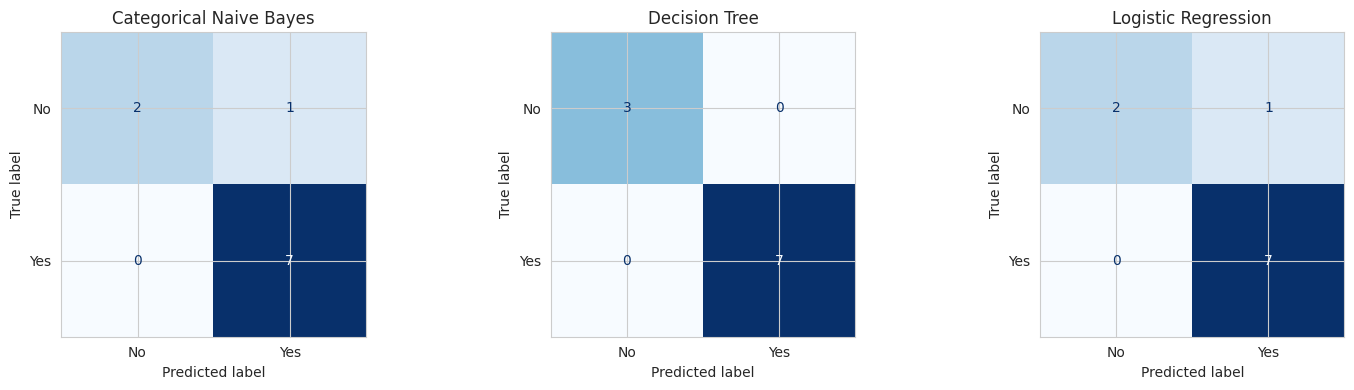

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, preds, title in zip(
    axes,
    [y_pred_nb, y_pred_dt, y_pred_lr],
    ["Categorical Naive Bayes", "Decision Tree", "Logistic Regression"]
):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=target_encoder.classes_).plot(
        ax=ax, cmap="Blues", values_format="d", colorbar=False
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [19]:
comparison = pd.DataFrame({
    "Model": ["Categorical Naive Bayes", "Decision Tree", "Logistic Regression"],
    "Accuracy": [acc_nb, acc_dt, acc_lr]
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

comparison

,Model,Accuracy
0,Decision Tree,1.0
1,Categorical Naive Bayes,0.9
2,Logistic Regression,0.9


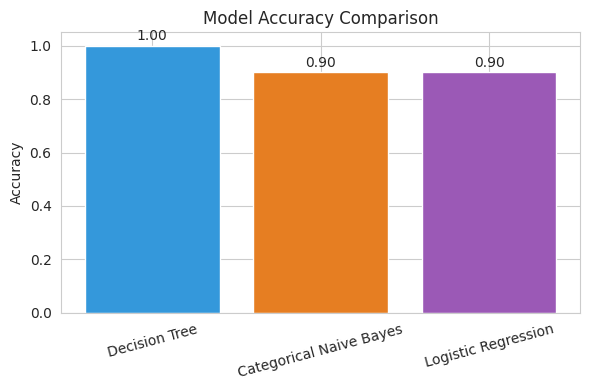

In [20]:
plt.figure(figsize=(6, 4))
bars = plt.bar(comparison["Model"], comparison["Accuracy"],
                color=["#3498db", "#e67e22", "#9b59b6"])
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
for bar, val in zip(bars, comparison["Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.2f}", ha="center")
plt.tight_layout()
plt.show()

## 11. Conclusion

- The **Categorical Naive Bayes** model is well suited to this dataset since every feature is genuinely categorical (nominal), and it models each feature's category-conditional probability directly without assuming any numeric ordering or feature independence structure beyond the Naive Bayes assumption itself.
- For the query weather condition **(Sunny, Cool, High, Strong)**, the model outputs both a predicted class and full class probabilities, which is a key advantage of Naive Bayes over models that only output hard labels.
- **Decision Tree** models can capture more complex, non-linear interaction rules between features (e.g. classic rules like "if Outlook=Sunny and Humidity=High then No"), which suits the well-known logical structure of the Play Tennis dataset.
- **Logistic Regression** models a linear decision boundary over the (one-hot encoded) feature space, and on such a small, non-linearly-separable dataset it may under- or over-fit depending on the particular train/test split.
- Given the very small dataset size (50 rows, 10 in the test split), accuracy scores can vary noticeably with the random seed — the comparison above should be read as illustrative rather than a definitive ranking of the algorithms.